### Without Short Term Memory (STM)

In [18]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig

In [2]:
load_dotenv()

True

In [4]:
model = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite')

In [6]:
def call_model(state: MessagesState):
    response = model.invoke(state['messages'])
    
    return {"messages": [response]}

In [8]:
builder = StateGraph(MessagesState)

builder.add_node('call_model', call_model)

builder.add_edge(START, "call_model")

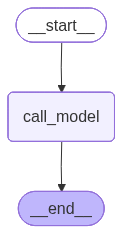

In [9]:
graph = builder.compile()

graph

In [11]:

graph.invoke({"messages": [HumanMessage(content="Hi! My name is Yash Kumar")]})

{'messages': [HumanMessage(content='Hi! My name is Yash Kumar', additional_kwargs={}, response_metadata={}, id='995dfa35-dcc0-4fa2-a7d0-71f6cb88b505'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Yash Kumar! It's a pleasure to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgERTTIPcv9xJ335dKnMnNtsaQHitEtFBMoSCyRsXGs+tOul7JXJ+uJL4phb9k6B4Sgq'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f43ea-c861-71a0-ab38-8ffc3e4759ac-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 28, 'total_tokens': 36, 'input_token_details': {'cache_read': 0}})]}

In [12]:
graph.invoke({"messages": [HumanMessage(content="What is my name?")]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='b6cc685a-c0e5-490e-9617-3f1541cf0ecc'),
  AIMessage(content=[{'type': 'text', 'text': 'I don’t know your name. As an AI, I don’t have access to your personal identity, private documents, or webcam unless you explicitly provide that information to me in this conversation.', 'extras': {'signature': 'EjQKMgERTTIPfvM3BV8clpu5B9je3XXQzvcnN7CSzF5vHn3b+lPhbaApTUcE2gzXjx9vfsNl'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f43eb-aea1-7431-9f1a-c992ab1badc0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 40, 'total_tokens': 46, 'input_token_details': {'cache_read': 0}})]}

### With Short Term Memory

In [13]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    
    return {"messages": [response]}

In [14]:
builder = StateGraph(MessagesState)

builder.add_node("call_model", call_model)

builder.add_edge(START, "call_model")

In [15]:
from langgraph.checkpoint.memory import InMemorySaver

checkpoint = InMemorySaver()

graph = builder.compile(checkpointer=checkpoint)

In [19]:
config = RunnableConfig(configurable= {"thread_id": "thread-1"})

In [21]:
graph.invoke({"messages": [HumanMessage(content="Hi! My name is Yash Kumar")]}, config)

{'messages': [HumanMessage(content='Hi! My name is Yash Kumar', additional_kwargs={}, response_metadata={}, id='923f6623-f489-40f9-aae2-332da68dce75'),
  AIMessage(content=[{'type': 'text', 'text': "Hello, Yash Kumar! It's a pleasure to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgERTTIPZjCSHL2XMmq0A5eAEiB5JS73QCZjK+MmL1iZNXkC2NRvuhzfIs7MOsVmJLQ0'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f43f6-a5aa-7d63-afa1-b2f4d9721b0c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 29, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}})]}

In [22]:
graph.invoke({"messages": [HumanMessage(content="What is my name?")]}, config)

{'messages': [HumanMessage(content='Hi! My name is Yash Kumar', additional_kwargs={}, response_metadata={}, id='923f6623-f489-40f9-aae2-332da68dce75'),
  AIMessage(content=[{'type': 'text', 'text': "Hello, Yash Kumar! It's a pleasure to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgERTTIPZjCSHL2XMmq0A5eAEiB5JS73QCZjK+MmL1iZNXkC2NRvuhzfIs7MOsVmJLQ0'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f43f6-a5aa-7d63-afa1-b2f4d9721b0c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 29, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='deb6122c-7d95-42e9-b3e3-48a5389aa038'),
  AIMessage(content=[{'type': 'text', 'text': 'Your name is Yash Kumar.', 'extra

In [23]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
    print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Yash Kumar
- AIMessage : [{'type': 'text', 'text': "Hello, Yash Kumar! It's a pleasure to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgERTTIPZjCSHL2XMmq0A5eAEiB5JS73QCZjK+MmL1iZNXkC2NRvuhzfIs7MOsVmJLQ0'}}]
- HumanMessage : What is my name?
- AIMessage : [{'type': 'text', 'text': 'Your name is Yash Kumar.', 'extras': {'signature': 'EjQKMgERTTIPTqxaqc0nFRTjtKhXgbPtY5lWZtI5FMmDocL7DmEZrO+wp12qrrTdnjvrJCJj'}}]
